## Pixel Forge GAN

In [28]:
!pip install tensorflow tensorflow-gpu matplotlib tensorflow-datasets ipywidgets

  Using cached tensorflow-gpu-2.12.0.tar.gz (2.6 kB)
  error: subprocess-exited-with-error
  
  × python setup.py egg_info did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Preparing metadata (setup.py) ... error
error: metadata-generation-failed

× Encountered error while generating package metadata.
╰─> See above for output.

note: This is an issue with the package mentioned above, not pip.
hint: See above for details.


#### 1. Setting up the environment

In [29]:
import tensorflow as tf
print("Check my GPU", tf.config.list_physical_devices("GPU"))

Check my GPU [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [30]:
physical_devices = tf.config.list_physical_devices("GPU")
if len(physical_devices) > 0:
    tf.config.experimental.set_memory_growth(physical_devices[0], True)
    print("GPU configured with memory growth")
else:
    print("No GPU detected")

GPU configured with memory growth


In [31]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.datasets import cifar10

#### 2. Prepare the Data Pipeline

This loads the Pixel Forge GAN dataset:
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

Since we only need the training images, we discard the test dataset:
X_train = X_train.astype("float32") / 255.0

In color images, pixel values range between 0 and 255 for each of the three RGB channels:

(0, 0, 0) → Black (No color)
(127, 127, 127) → Medium Gray (Equal intensity in all channels)
(255, 255, 255) → White (Maximum intensity in all channels)
Each image in the dataset is represented as a 32×32×3 array, where 3 corresponds to the Red, Green, and Blue (RGB) channels.

In [32]:
# Load dataset
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

Since CIFAR-10 consists of color images, the shape of X_train is:

In [33]:
print(X_train.shape)
print(X_test.shape)

(50000, 32, 32, 3)
(10000, 32, 32, 3)


50000 training images, each of size 32x32 pixels with 3 color channels (RGB).

10000 test images, each with the same format.

[]

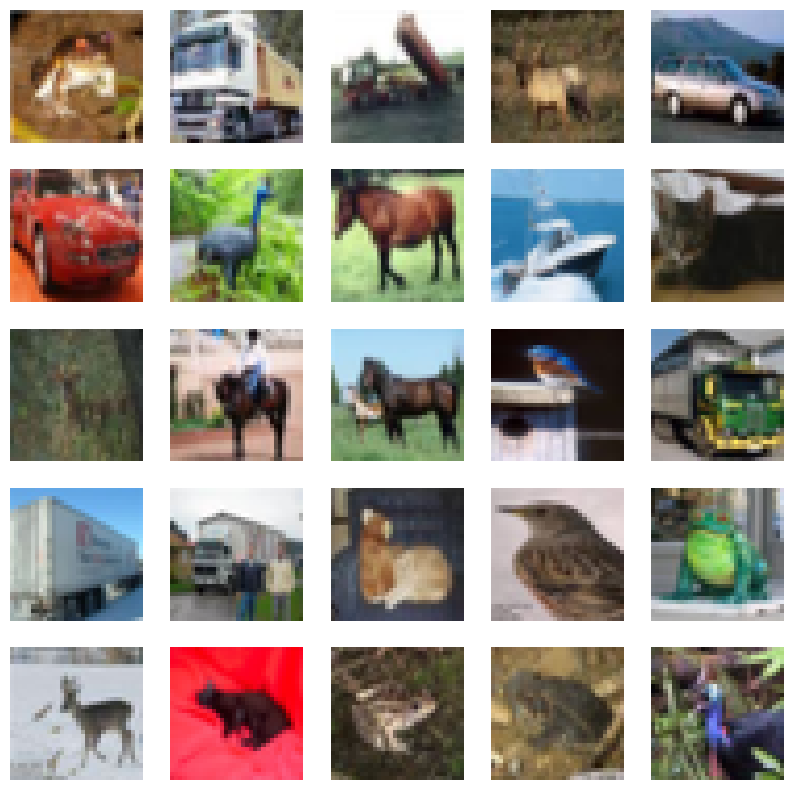

In [34]:
# Displaying some of the dataset
plt.figure(figsize=(10, 10))
for i in range (25):
  plt.subplot(5, 5, i+1)
  plt.imshow(X_train[i])
  plt.axis("off")
plt.plot()

#### Normalizing the Dataset

X_train.shape[0] → Represents the number of images (50,000 in CIFAR-10).
32, 32, 3 → Each image is 32×32 pixels with 3 color channels (RGB).

#### Processing for Color Images

In [35]:
# Convert pixel values to floating-point numbers for efficient neural network processing
X_train = X_train.astype("float32")

In [36]:
# Normalize pixel values from [0, 255] to [-1, 1] (GANs work better in this range)
X_train = (X_train - 127.5) / 127.5

In [37]:
X_train.shape

(50000, 32, 32, 3)

BUFFER_SIZE = 50000 → Since CIFAR-10 has 50,000 training images, setting the buffer size to this value ensures a full shuffle of the dataset every epoch, preventing the model from memorizing image order.

BATCH_SIZE = 256 → Controls how many images are processed in each training step. A higher batch size speeds up training but requires more memory, while a lower batch size reduces memory usage but may slow training.

In [38]:
# Ensures complete shuffling of the CIFAR-10 dataset each epoch for diverse training.
BUFFER_SIZE = 50000

In [39]:
# Determines the number of images processed at once, balancing memory usage and training efficiency.
BATCH_SIZE = 256

In [40]:
X_train

array([[[[-0.5372549 , -0.5137255 , -0.5058824 ],
         [-0.6627451 , -0.6392157 , -0.64705884],
         [-0.60784316, -0.62352943, -0.6627451 ],
         ...,
         [ 0.23921569,  0.03529412, -0.15294118],
         [ 0.19215687, -0.01960784, -0.2       ],
         [ 0.16078432, -0.02745098, -0.19215687]],

        [[-0.8745098 , -0.84313726, -0.84313726],
         [-1.        , -1.        , -1.        ],
         [-0.85882354, -0.9372549 , -1.        ],
         ...,
         [-0.03529412, -0.30980393, -0.5686275 ],
         [-0.06666667, -0.34901962, -0.60784316],
         [-0.04313726, -0.31764707, -0.5529412 ]],

        [[-0.8039216 , -0.8117647 , -0.8352941 ],
         [-0.8745098 , -0.94509804, -1.        ],
         [-0.6156863 , -0.7882353 , -0.9372549 ],
         ...,
         [-0.07450981, -0.34117648, -0.60784316],
         [-0.05882353, -0.34117648, -0.60784316],
         [-0.14509805, -0.42745098, -0.67058825]],

        ...,

        [[ 0.6313726 ,  0.33333334, -0

Before batching: (50000, 32, 32, 3) → 50,000 individual color images (CIFAR-10).

After batching: (256, 32, 32, 3) → Each batch contains 256 images.

Total number of batches per epoch: 50000 / 256 ≈ 196



In [41]:
# Create the tensorflow dataset
train_dataset = tf.data.Dataset.from_tensor_slices(X_train).shuffle(BUFFER_SIZE).batch(BATCH_SIZE)

Mean (mean=0.0): Commonly used in GANs to initialize weights. A small non-zero mean (e.g., mean=0.01 or mean=0.02) can sometimes improve training stability and convergence speed.

Standard Deviation (stddev=0.02): Recommended by research (DCGAN paper) as it helps GANs generate sharper and more realistic images. It ensures the network starts with balanced gradients, preventing instability during training.

In [42]:
LATENT_DIM = 100
WEIGHT_UNIT = keras.initializers.RandomNormal(mean=0.8, stddev=0.02)

#### 3. Define the Generator and Discriminator

In [43]:
def build_generator():
    model = keras.Sequential([
        layers.Dense(8 * 8 * 256, use_bias=False, input_shape=(LATENT_DIM,)),
        layers.BatchNormalization(),
        layers.LeakyReLU(),

        # Reshape into 8x8x256 feature map
        layers.Reshape((8, 8, 256)),

        layers.Conv2DTranspose(128, (5, 5), strides=(1, 1), padding="same", use_bias=False),
        layers.BatchNormalization(),
        layers.LeakyReLU(0.2),

        layers.Conv2DTranspose(128, (5, 5), strides=(2, 2), padding="same", use_bias=False),
        layers.BatchNormalization(),
        layers.LeakyReLU(0.2),

        layers.Conv2DTranspose(64, (5, 5), strides=(2, 2), padding="same", use_bias=False),
        layers.BatchNormalization(),
        layers.LeakyReLU(0.2),

        # Output layer: 3 channels (RGB), tanh activation for [-1,1] range
        layers.Conv2DTranspose(3, (5, 5), strides=(1, 1), padding="same", use_bias=False, activation="tanh")
    ])

    return model

generator = build_generator()
generator.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                      │ (None, 16384)               │       1,638,400 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_8                │ (None, 16384)               │          65,536 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ leaky_re_lu_11 (LeakyReLU)           │ (None, 16384)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ reshape_2 (Reshape)                  │ (None, 8, 8, 256)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_transpose_8 (Conv2DTranspose) │ (None, 8, 8, 128)           │         819,200 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_9                │ (None, 8, 8, 128)           │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ leaky_re_lu_12 (LeakyReLU)           │ (None, 8, 8, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_transpose_9 (Conv2DTranspose) │ (None, 16, 16, 128)         │         409,600 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_10               │ (None, 16, 16, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ leaky_re_lu_13 (LeakyReLU)           │ (None, 16, 16, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_transpose_10                  │ (None, 32, 32, 64)          │         204,800 │
│ (Conv2DTranspose)                    │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_11               │ (None, 32, 32, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ leaky_re_lu_14 (LeakyReLU)           │ (None, 32, 32, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_transpose_11                  │ (None, 32, 32, 3)           │           4,800 │
│ (Conv2DTranspose)                    │                             │                 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,143,616 (11.99 MB)

 Trainable params: 3,110,208 (11.86 MB)

 Non-trainable params: 33,408 (130.50 KB)

In [44]:
def build_discriminator():
    model = keras.Sequential([
        # First Conv2D layer: Detects low-level features (edges, textures, etc.)
        layers.Conv2D(64, (5, 5), strides=(2, 2), padding="same", input_shape=(32, 32, 3)),
        layers.LeakyReLU(0.2),
        layers.Dropout(0.3),

        # Second Conv2D layer: Learns more complex features
        layers.Conv2D(128, (5, 5), strides=(2, 2), padding="same"),
        layers.LeakyReLU(0.2),
        layers.Dropout(0.3),

        # Third Conv2D layer: Extracts deeper features
        layers.Conv2D(256, (5, 5), strides=(2, 2), padding="same"),
        layers.LeakyReLU(0.2),
        layers.Dropout(0.3),

        # Flatten the 2D feature maps into a 1D vector for classification
        layers.Flatten(),

        # Output layer: Sigmoid activation for binary classification (real/fake)
        layers.Dense(1, activation="sigmoid")
    ])

    return model

discriminator = build_discriminator()
discriminator.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)                    │ (None, 16, 16, 64)          │           4,864 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ leaky_re_lu_15 (LeakyReLU)           │ (None, 16, 16, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 16, 16, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 8, 8, 128)           │         204,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ leaky_re_lu_16 (LeakyReLU)           │ (None, 8, 8, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ (None, 8, 8, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (None, 4, 4, 256)           │         819,456 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ leaky_re_lu_17 (LeakyReLU)           │ (None, 4, 4, 256)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_5 (Dropout)                  │ (None, 4, 4, 256)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 4096)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 1)                   │           4,097 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,033,345 (3.94 MB)

 Trainable params: 1,033,345 (3.94 MB)

 Non-trainable params: 0 (0.00 B)

In [45]:
cross_entropy = keras.losses.BinaryCrossentropy()

#### 4. Build a Custom Training Loop

In [46]:
# Create the discriminator loss
def discriminator_loss(real_output, fake_output):
  # Calculates the loss when the discriminator classifies real images
  real_loss = cross_entropy(tf.ones_like(real_output), real_output)

  # Calculates the loss when the discriminator classifies fake images
  fake_loss = cross_entropy(tf.zeros_like(fake_output), fake_output)

  # Return the sum of both losses
  return real_loss + fake_loss

In [47]:
def generator_loss(fake_output):
  return cross_entropy(tf.ones_like(fake_output), fake_output)

In [48]:
generator_optimizer = keras.optimizers.Adam(learning_rate=0.0002, beta_1=0.5)
discriminator_optimizer = keras.optimizers.Adam(learning_rate=0.0002, beta_1=0.5)

In [49]:
# Building our subclass model
class GAN(keras.Model):
  def __init__(self, generator, discriminator):
    # Initialize the GAN model with the generator and discriminator
    super(GAN, self).__init__()
    self.generator = generator  # Set generator model
    self.discriminator = discriminator  # Set discriminator model

  def compile(self, g_optimizer, d_optimizer, g_loss, d_loss):
    super(GAN, self).compile()
    self.g_optimizer = g_optimizer  # Set the generator optimizer
    self.d_optimizer = d_optimizer  # Set the discriminator optimizer
    self.g_loss = g_loss  # Set the generator loss
    self.d_loss = d_loss  # Set the discriminator loss

  def train_step(self, real_images):
    # Training logic
    batch_size = tf.shape(real_images)[0]

    # Train discriminator
    noise = tf.random.normal([batch_size, LATENT_DIM])
    with tf.GradientTape() as d_tape:
        generated_images = self.generator(noise)
        real_output = self.discriminator(real_images)
        fake_output = self.discriminator(generated_images)
        d_loss = self.d_loss(real_output, fake_output)

    # Computing the gradients for the discriminator based on its loss
    d_gradients = d_tape.gradient(d_loss, self.discriminator.trainable_variables)
    self.d_optimizer.apply_gradients(zip(d_gradients, self.discriminator.trainable_variables))

    # Train generator
    noise = tf.random.normal([batch_size, LATENT_DIM])
    with tf.GradientTape() as g_tape:
        generated_images = self.generator(noise)
        fake_output = self.discriminator(generated_images)
        g_loss = self.g_loss(fake_output)

    g_gradients = g_tape.gradient(g_loss, self.generator.trainable_variables)
    self.g_optimizer.apply_gradients(zip(g_gradients, self.generator.trainable_variables))

    return {"d_loss": d_loss, "g_loss": g_loss}


#### 5. Implement Callbacks for Monitoring

In [50]:
class ImageCallback(keras.callbacks.Callback):
  def __init__(self, num_images=16, latent_dim=100):
    self.num_images = num_images
    self.latent_dim = latent_dim
    self.seed = tf.random.normal([num_images, latent_dim])

  def on_epoch_end(self, epoch, logs=None):
    if epoch % 5 == 0:
      generated_images = self.model.generator(self.seed)
      generated_images = (generated_images * 127.5) + 127.5  # Rescale to range [0, 255]
      generated_images = tf.clip_by_value(generated_images, 0, 255)  # Ensure values are in the correct range

      plt.figure(figsize=(10, 10))
      for i in range(self.num_images):
        plt.subplot(4, 4, i + 1)
        plt.imshow(generated_images[i].numpy().astype("uint8"))  # Remove cmap="gray" for color images
        plt.axis("off")
      plt.show()

#### 6. Train and Compile the Model

In [51]:
EPOCH = 100

In [52]:
gan = GAN(generator=generator, discriminator=discriminator)

gan.compile(
    g_optimizer=generator_optimizer,
    d_optimizer=discriminator_optimizer,
    g_loss=generator_loss,
    d_loss=discriminator_loss
)

Epoch 1/100
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 154ms/step - d_loss: 1.0365 - g_loss: 1.3088

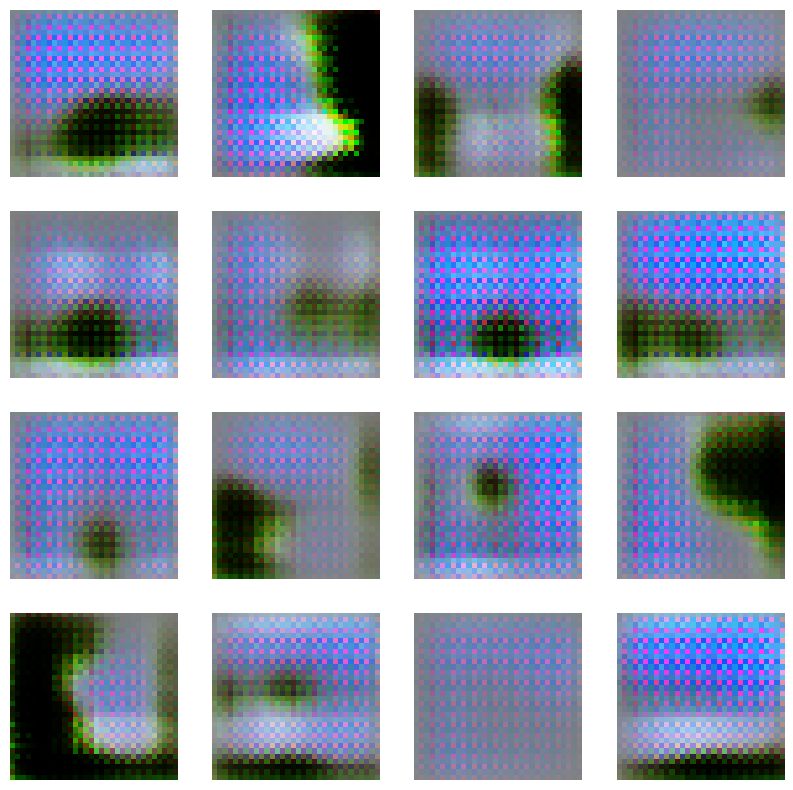

196/196 ━━━━━━━━━━━━━━━━━━━━ 51s 161ms/step - d_loss: 1.0364 - g_loss: 1.3084
Epoch 2/100
196/196 ━━━━━━━━━━━━━━━━━━━━ 25s 128ms/step - d_loss: 1.1686 - g_loss: 1.5334
Epoch 3/100
196/196 ━━━━━━━━━━━━━━━━━━━━ 24s 124ms/step - d_loss: 1.1817 - g_loss: 1.2422
Epoch 4/100
196/196 ━━━━━━━━━━━━━━━━━━━━ 24s 123ms/step - d_loss: 1.1930 - g_loss: 1.2889
Epoch 5/100
196/196 ━━━━━━━━━━━━━━━━━━━━ 41s 125ms/step - d_loss: 1.2253 - g_loss: 1.0871
Epoch 6/100
195/196 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step - d_loss: 1.2929 - g_loss: 0.9223

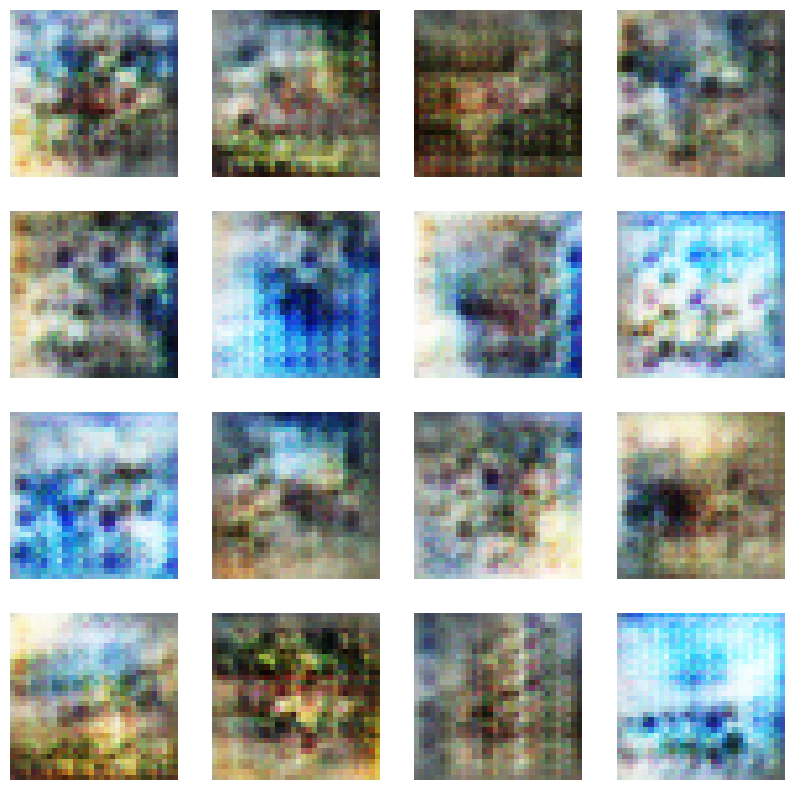

196/196 ━━━━━━━━━━━━━━━━━━━━ 41s 127ms/step - d_loss: 1.2940 - g_loss: 0.9215
Epoch 7/100
196/196 ━━━━━━━━━━━━━━━━━━━━ 25s 125ms/step - d_loss: 1.3080 - g_loss: 0.9025
Epoch 8/100
196/196 ━━━━━━━━━━━━━━━━━━━━ 24s 123ms/step - d_loss: 1.2847 - g_loss: 0.9720
Epoch 9/100
196/196 ━━━━━━━━━━━━━━━━━━━━ 41s 125ms/step - d_loss: 1.2689 - g_loss: 0.9520
Epoch 10/100
196/196 ━━━━━━━━━━━━━━━━━━━━ 25s 128ms/step - d_loss: 1.2962 - g_loss: 0.9153
Epoch 11/100
195/196 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: 1.2928 - g_loss: 0.9583

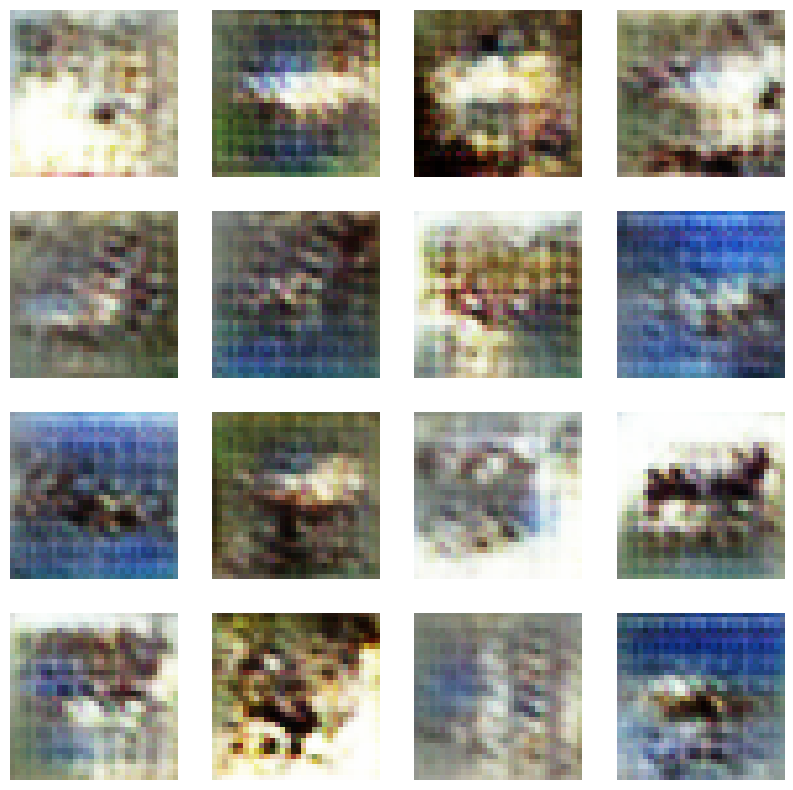

196/196 ━━━━━━━━━━━━━━━━━━━━ 25s 125ms/step - d_loss: 1.2930 - g_loss: 0.9577
Epoch 12/100
196/196 ━━━━━━━━━━━━━━━━━━━━ 41s 124ms/step - d_loss: 1.2995 - g_loss: 0.9451
Epoch 13/100
196/196 ━━━━━━━━━━━━━━━━━━━━ 25s 128ms/step - d_loss: 1.2985 - g_loss: 0.9346
Epoch 14/100
196/196 ━━━━━━━━━━━━━━━━━━━━ 24s 123ms/step - d_loss: 1.2880 - g_loss: 0.9644
Epoch 15/100
196/196 ━━━━━━━━━━━━━━━━━━━━ 41s 124ms/step - d_loss: 1.2879 - g_loss: 0.9775
Epoch 16/100
195/196 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step - d_loss: 1.3194 - g_loss: 0.9500

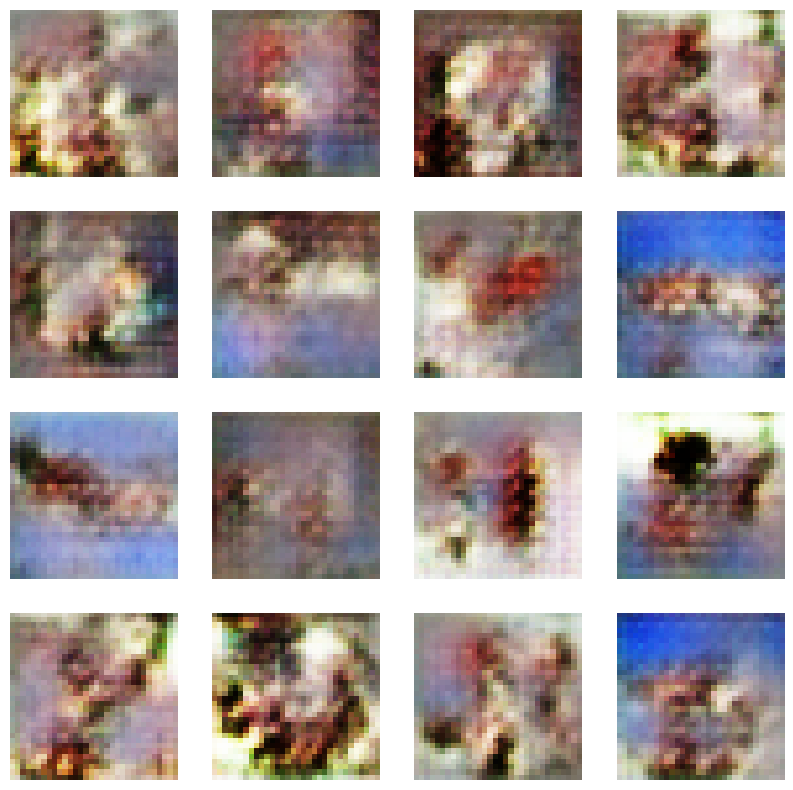

196/196 ━━━━━━━━━━━━━━━━━━━━ 42s 129ms/step - d_loss: 1.3193 - g_loss: 0.9495
Epoch 17/100
196/196 ━━━━━━━━━━━━━━━━━━━━ 25s 126ms/step - d_loss: 1.3183 - g_loss: 0.9276
Epoch 18/100
196/196 ━━━━━━━━━━━━━━━━━━━━ 24s 122ms/step - d_loss: 1.3020 - g_loss: 0.9330
Epoch 19/100
196/196 ━━━━━━━━━━━━━━━━━━━━ 24s 124ms/step - d_loss: 1.3083 - g_loss: 0.9342
Epoch 20/100
196/196 ━━━━━━━━━━━━━━━━━━━━ 41s 125ms/step - d_loss: 1.3112 - g_loss: 0.9181
Epoch 21/100
195/196 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step - d_loss: 1.3176 - g_loss: 0.8929

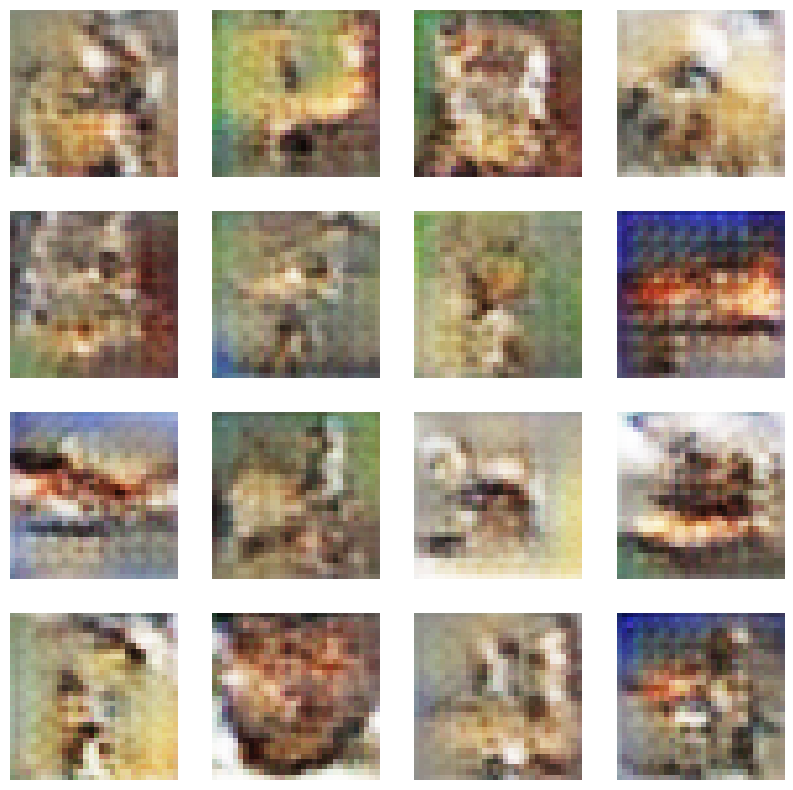

196/196 ━━━━━━━━━━━━━━━━━━━━ 25s 129ms/step - d_loss: 1.3196 - g_loss: 0.8923
Epoch 22/100
196/196 ━━━━━━━━━━━━━━━━━━━━ 24s 123ms/step - d_loss: 1.3223 - g_loss: 0.9073
Epoch 23/100
196/196 ━━━━━━━━━━━━━━━━━━━━ 24s 124ms/step - d_loss: 1.3266 - g_loss: 0.8835
Epoch 24/100
196/196 ━━━━━━━━━━━━━━━━━━━━ 25s 125ms/step - d_loss: 1.3243 - g_loss: 0.8527
Epoch 25/100
196/196 ━━━━━━━━━━━━━━━━━━━━ 41s 124ms/step - d_loss: 1.3339 - g_loss: 0.8647
Epoch 26/100
195/196 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step - d_loss: 1.3238 - g_loss: 0.8702

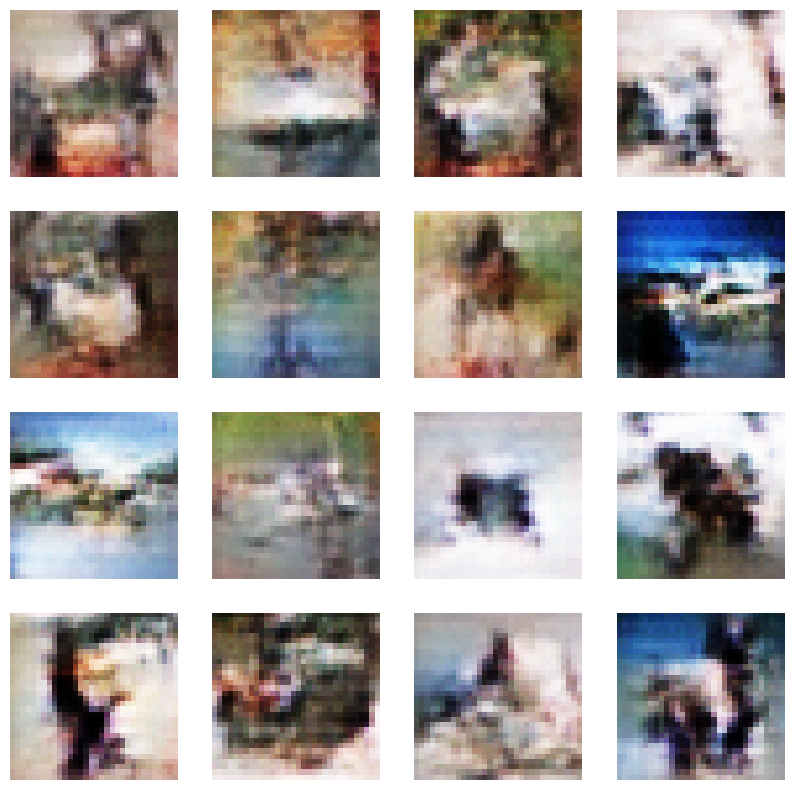

196/196 ━━━━━━━━━━━━━━━━━━━━ 25s 129ms/step - d_loss: 1.3240 - g_loss: 0.8713
Epoch 27/100
196/196 ━━━━━━━━━━━━━━━━━━━━ 24s 123ms/step - d_loss: 1.3366 - g_loss: 0.8553
Epoch 28/100
196/196 ━━━━━━━━━━━━━━━━━━━━ 24s 123ms/step - d_loss: 1.3423 - g_loss: 0.8285
Epoch 29/100
196/196 ━━━━━━━━━━━━━━━━━━━━ 41s 125ms/step - d_loss: 1.3425 - g_loss: 0.8303
Epoch 30/100
196/196 ━━━━━━━━━━━━━━━━━━━━ 25s 127ms/step - d_loss: 1.3490 - g_loss: 0.8106
Epoch 31/100
195/196 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: 1.3517 - g_loss: 0.7961

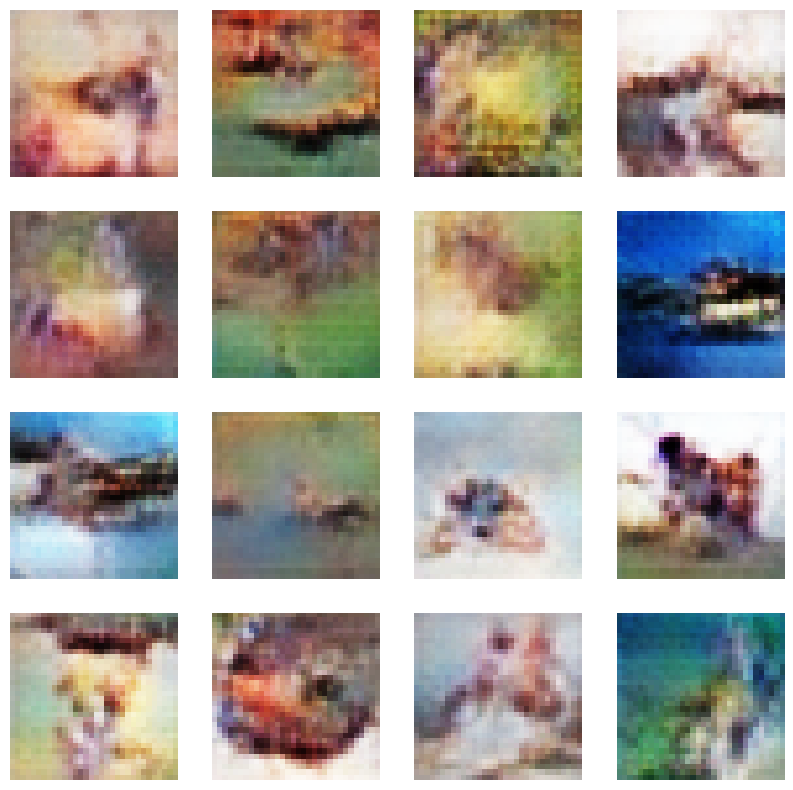

196/196 ━━━━━━━━━━━━━━━━━━━━ 24s 124ms/step - d_loss: 1.3511 - g_loss: 0.7959
Epoch 32/100
196/196 ━━━━━━━━━━━━━━━━━━━━ 24s 123ms/step - d_loss: 1.3499 - g_loss: 0.7984
Epoch 33/100
196/196 ━━━━━━━━━━━━━━━━━━━━ 24s 125ms/step - d_loss: 1.3529 - g_loss: 0.7953
Epoch 34/100
196/196 ━━━━━━━━━━━━━━━━━━━━ 24s 124ms/step - d_loss: 1.3546 - g_loss: 0.7975
Epoch 35/100
196/196 ━━━━━━━━━━━━━━━━━━━━ 24s 123ms/step - d_loss: 1.3620 - g_loss: 0.7944
Epoch 36/100
195/196 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - d_loss: 1.3578 - g_loss: 0.7911

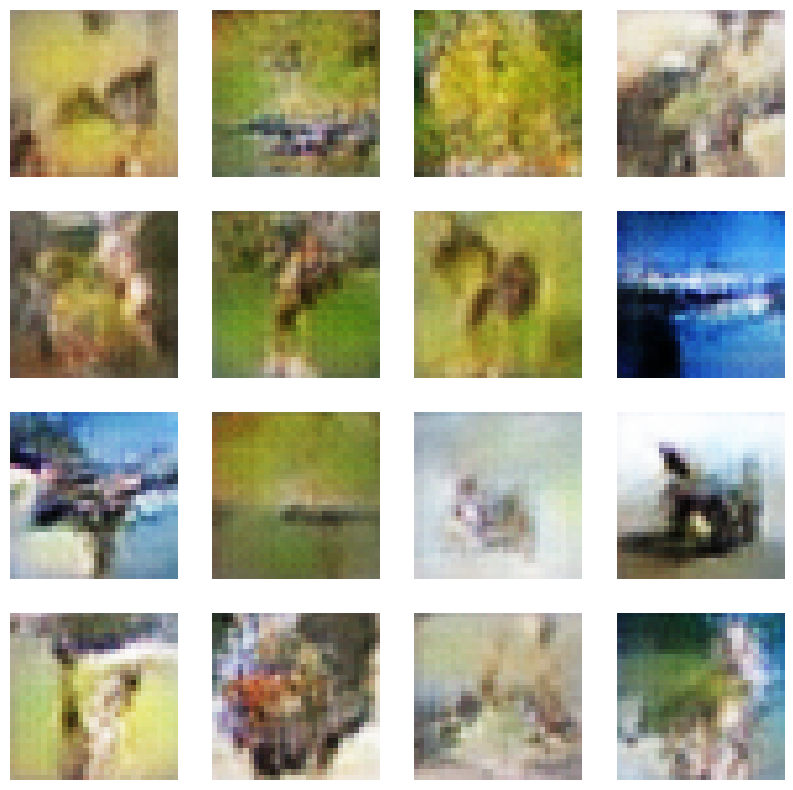

196/196 ━━━━━━━━━━━━━━━━━━━━ 25s 125ms/step - d_loss: 1.3568 - g_loss: 0.7907
Epoch 37/100
196/196 ━━━━━━━━━━━━━━━━━━━━ 24s 124ms/step - d_loss: 1.3588 - g_loss: 0.7840
Epoch 38/100
196/196 ━━━━━━━━━━━━━━━━━━━━ 41s 124ms/step - d_loss: 1.3557 - g_loss: 0.7774
Epoch 39/100
196/196 ━━━━━━━━━━━━━━━━━━━━ 25s 127ms/step - d_loss: 1.3595 - g_loss: 0.7823
Epoch 40/100
196/196 ━━━━━━━━━━━━━━━━━━━━ 40s 123ms/step - d_loss: 1.3593 - g_loss: 0.7865
Epoch 41/100
195/196 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step - d_loss: 1.3618 - g_loss: 0.7823

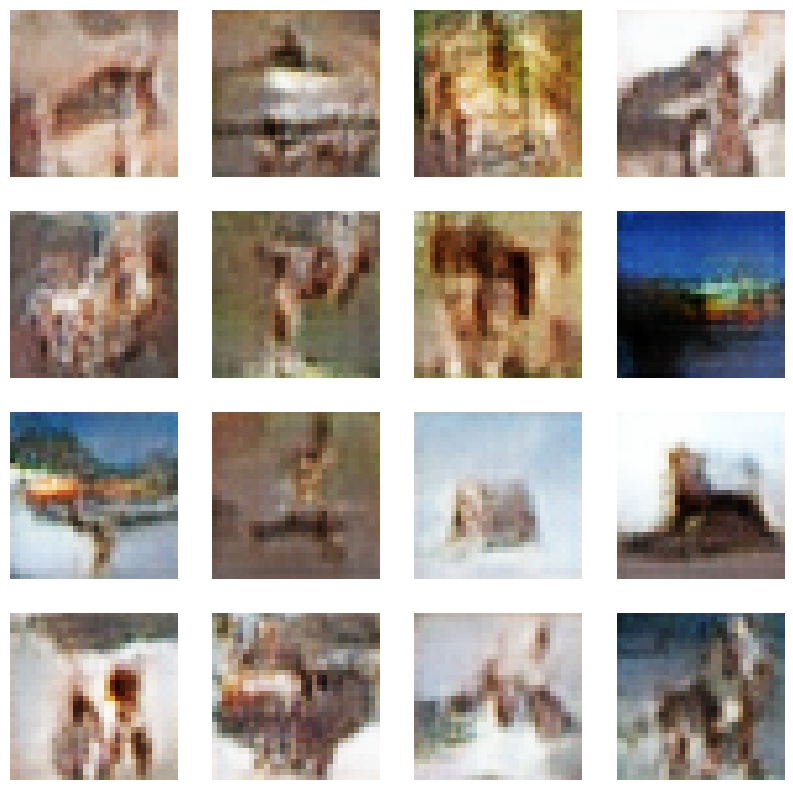

196/196 ━━━━━━━━━━━━━━━━━━━━ 26s 130ms/step - d_loss: 1.3615 - g_loss: 0.7818
Epoch 42/100
196/196 ━━━━━━━━━━━━━━━━━━━━ 40s 123ms/step - d_loss: 1.3598 - g_loss: 0.7735
Epoch 43/100
196/196 ━━━━━━━━━━━━━━━━━━━━ 25s 128ms/step - d_loss: 1.3606 - g_loss: 0.7752
Epoch 44/100
196/196 ━━━━━━━━━━━━━━━━━━━━ 24s 124ms/step - d_loss: 1.3614 - g_loss: 0.7762
Epoch 45/100
196/196 ━━━━━━━━━━━━━━━━━━━━ 24s 123ms/step - d_loss: 1.3616 - g_loss: 0.7817
Epoch 46/100
195/196 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step - d_loss: 1.3586 - g_loss: 0.7629

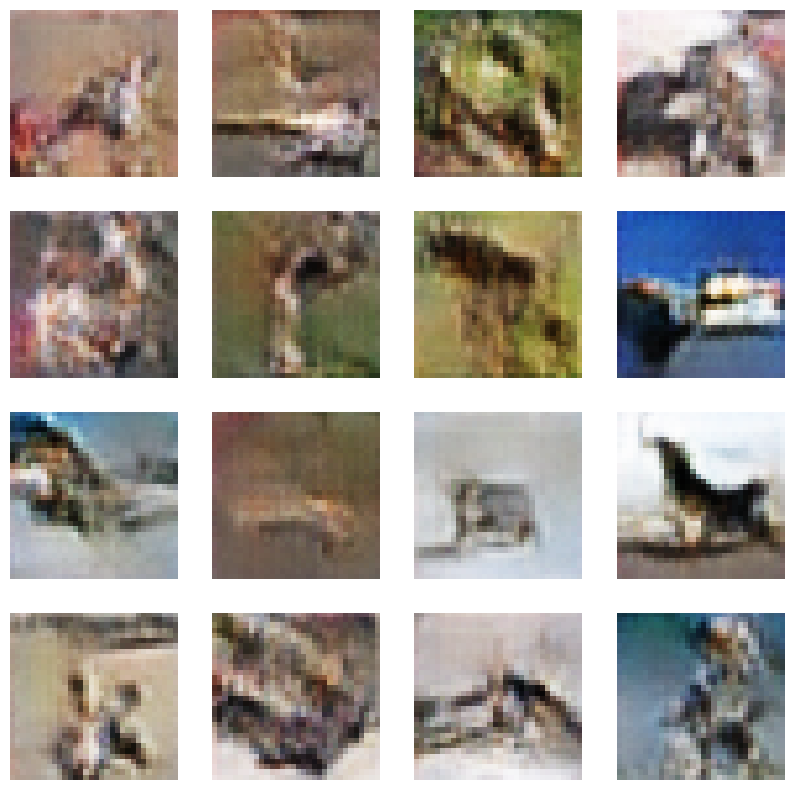

196/196 ━━━━━━━━━━━━━━━━━━━━ 42s 126ms/step - d_loss: 1.3584 - g_loss: 0.7628
Epoch 47/100
196/196 ━━━━━━━━━━━━━━━━━━━━ 25s 127ms/step - d_loss: 1.3639 - g_loss: 0.7797
Epoch 48/100
196/196 ━━━━━━━━━━━━━━━━━━━━ 40s 123ms/step - d_loss: 1.3650 - g_loss: 0.7747
Epoch 49/100
196/196 ━━━━━━━━━━━━━━━━━━━━ 42s 127ms/step - d_loss: 1.3585 - g_loss: 0.7741
Epoch 50/100
196/196 ━━━━━━━━━━━━━━━━━━━━ 24s 125ms/step - d_loss: 1.3601 - g_loss: 0.7706
Epoch 51/100
195/196 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: 1.3630 - g_loss: 0.7719

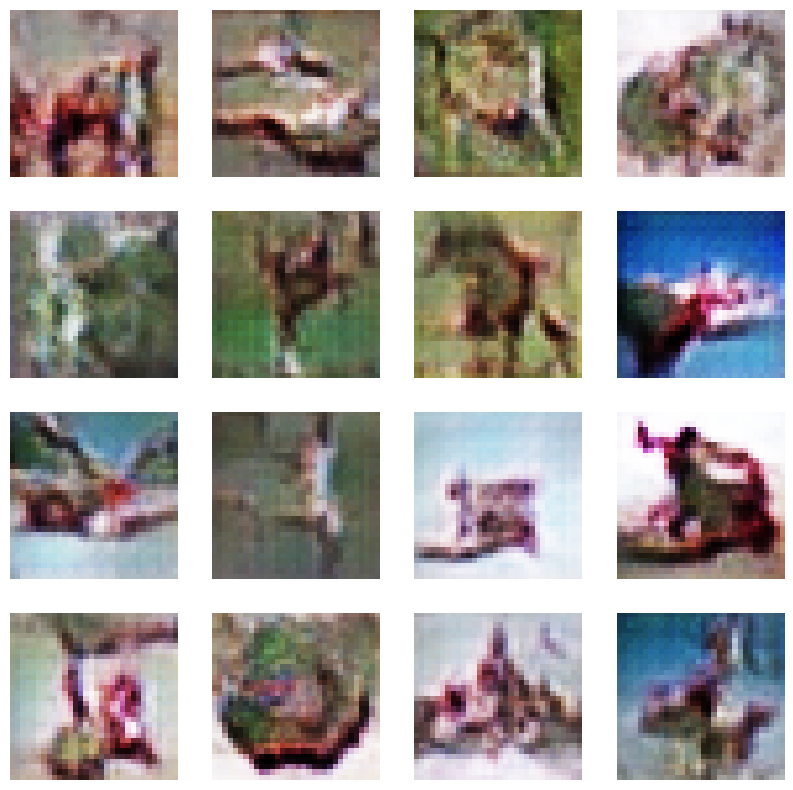

196/196 ━━━━━━━━━━━━━━━━━━━━ 24s 124ms/step - d_loss: 1.3628 - g_loss: 0.7730
Epoch 52/100
196/196 ━━━━━━━━━━━━━━━━━━━━ 24s 124ms/step - d_loss: 1.3639 - g_loss: 0.7747
Epoch 53/100
196/196 ━━━━━━━━━━━━━━━━━━━━ 25s 125ms/step - d_loss: 1.3581 - g_loss: 0.7658
Epoch 54/100
196/196 ━━━━━━━━━━━━━━━━━━━━ 41s 124ms/step - d_loss: 1.3599 - g_loss: 0.7654
Epoch 55/100
196/196 ━━━━━━━━━━━━━━━━━━━━ 42s 127ms/step - d_loss: 1.3590 - g_loss: 0.7723
Epoch 56/100
195/196 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - d_loss: 1.3587 - g_loss: 0.7715

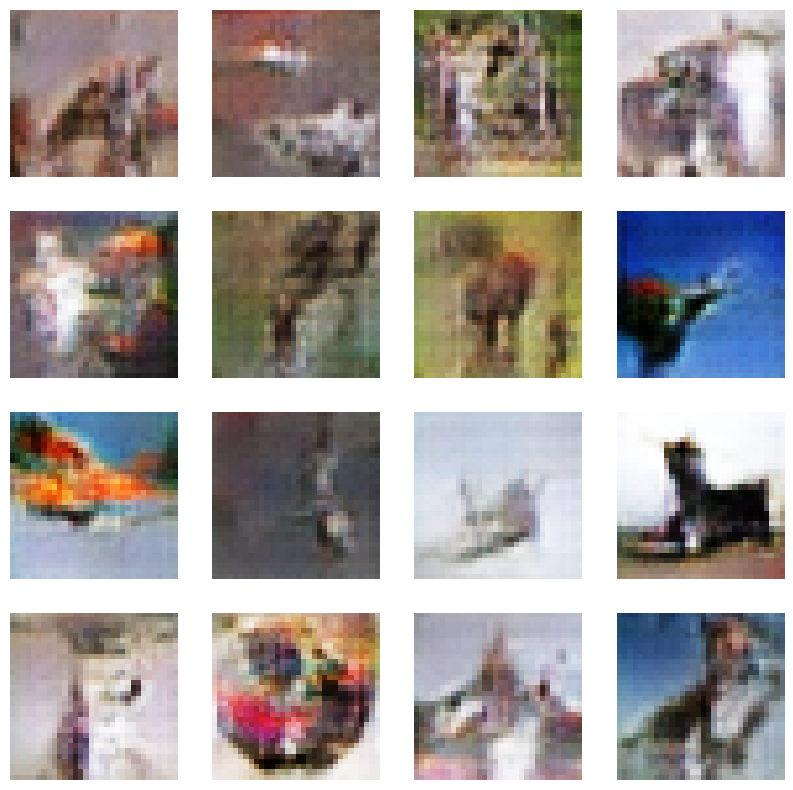

196/196 ━━━━━━━━━━━━━━━━━━━━ 41s 125ms/step - d_loss: 1.3585 - g_loss: 0.7717
Epoch 57/100
196/196 ━━━━━━━━━━━━━━━━━━━━ 25s 127ms/step - d_loss: 1.3610 - g_loss: 0.7708
Epoch 58/100
196/196 ━━━━━━━━━━━━━━━━━━━━ 40s 123ms/step - d_loss: 1.3552 - g_loss: 0.7770
Epoch 59/100
196/196 ━━━━━━━━━━━━━━━━━━━━ 25s 128ms/step - d_loss: 1.3595 - g_loss: 0.7789
Epoch 60/100
196/196 ━━━━━━━━━━━━━━━━━━━━ 24s 124ms/step - d_loss: 1.3547 - g_loss: 0.7734
Epoch 61/100
195/196 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - d_loss: 1.3559 - g_loss: 0.7722

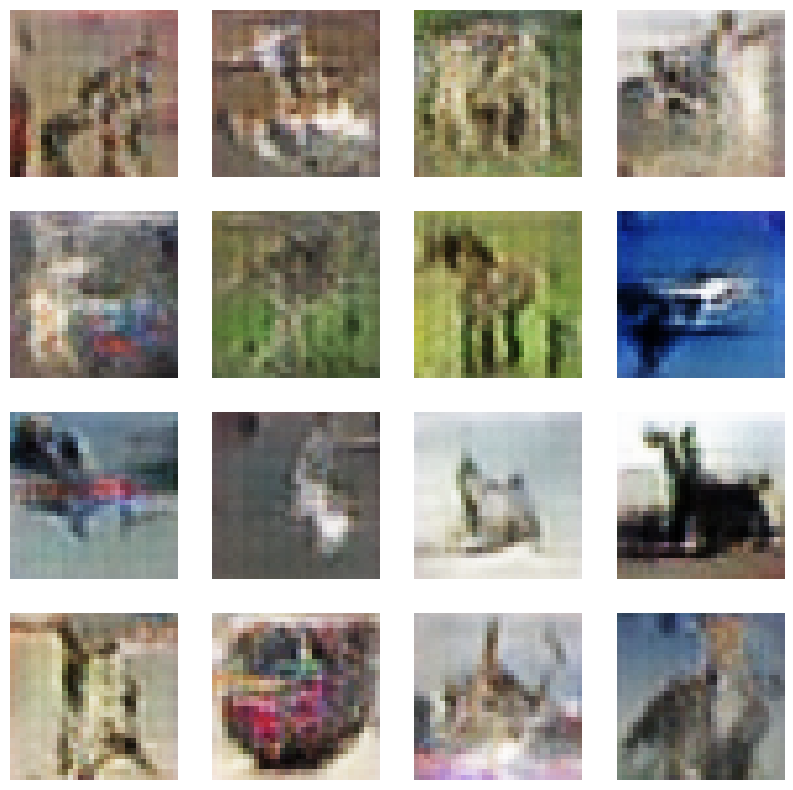

196/196 ━━━━━━━━━━━━━━━━━━━━ 24s 124ms/step - d_loss: 1.3555 - g_loss: 0.7723
Epoch 62/100
196/196 ━━━━━━━━━━━━━━━━━━━━ 25s 125ms/step - d_loss: 1.3537 - g_loss: 0.7769
Epoch 63/100
196/196 ━━━━━━━━━━━━━━━━━━━━ 25s 125ms/step - d_loss: 1.3522 - g_loss: 0.7764
Epoch 64/100
196/196 ━━━━━━━━━━━━━━━━━━━━ 24s 124ms/step - d_loss: 1.3517 - g_loss: 0.7832
Epoch 65/100
196/196 ━━━━━━━━━━━━━━━━━━━━ 41s 124ms/step - d_loss: 1.3515 - g_loss: 0.7777
Epoch 66/100
195/196 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step - d_loss: 1.3530 - g_loss: 0.7851

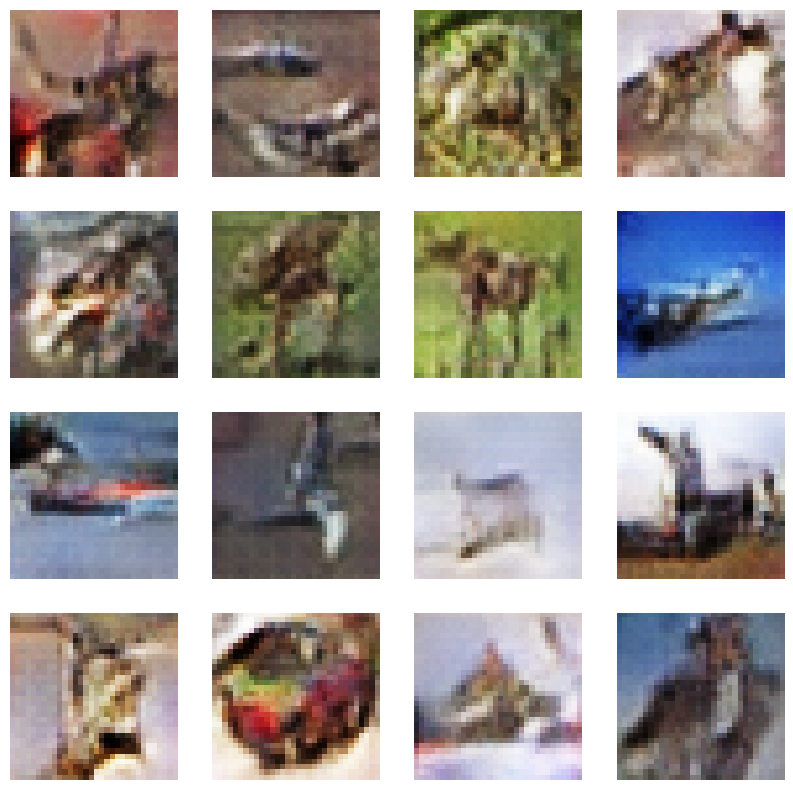

196/196 ━━━━━━━━━━━━━━━━━━━━ 42s 128ms/step - d_loss: 1.3531 - g_loss: 0.7855
Epoch 67/100
196/196 ━━━━━━━━━━━━━━━━━━━━ 25s 125ms/step - d_loss: 1.3472 - g_loss: 0.7856
Epoch 68/100
196/196 ━━━━━━━━━━━━━━━━━━━━ 41s 123ms/step - d_loss: 1.3459 - g_loss: 0.7784
Epoch 69/100
196/196 ━━━━━━━━━━━━━━━━━━━━ 25s 128ms/step - d_loss: 1.3518 - g_loss: 0.7868
Epoch 70/100
196/196 ━━━━━━━━━━━━━━━━━━━━ 24s 124ms/step - d_loss: 1.3479 - g_loss: 0.7760
Epoch 71/100
195/196 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step - d_loss: 1.3454 - g_loss: 0.7781

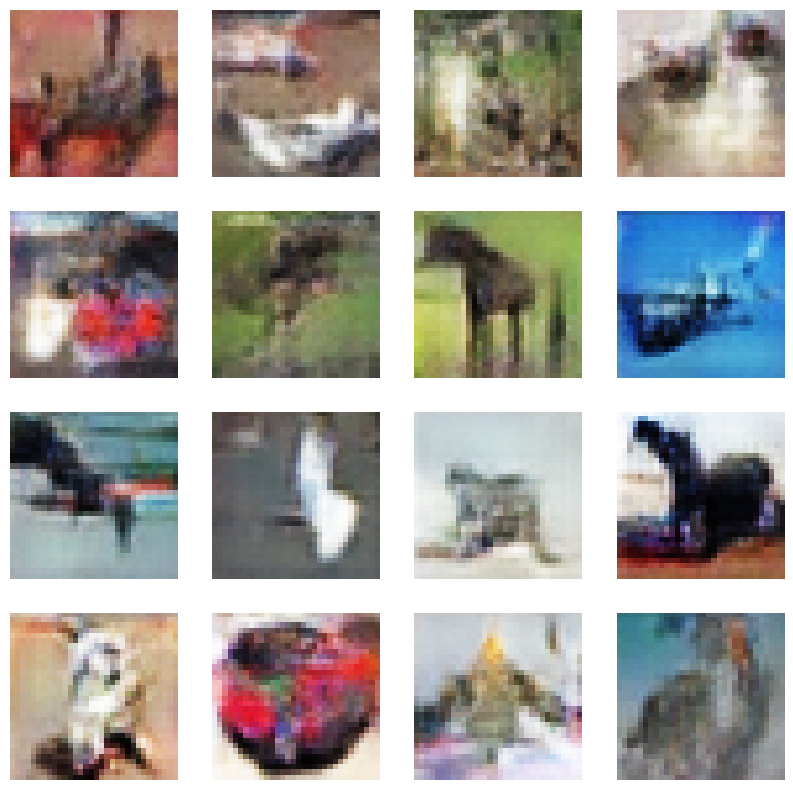

196/196 ━━━━━━━━━━━━━━━━━━━━ 42s 129ms/step - d_loss: 1.3447 - g_loss: 0.7778
Epoch 72/100
196/196 ━━━━━━━━━━━━━━━━━━━━ 41s 127ms/step - d_loss: 1.3487 - g_loss: 0.7853
Epoch 73/100
196/196 ━━━━━━━━━━━━━━━━━━━━ 25s 125ms/step - d_loss: 1.3455 - g_loss: 0.7894
Epoch 74/100
196/196 ━━━━━━━━━━━━━━━━━━━━ 40s 122ms/step - d_loss: 1.3427 - g_loss: 0.7830
Epoch 75/100
196/196 ━━━━━━━━━━━━━━━━━━━━ 42s 128ms/step - d_loss: 1.3422 - g_loss: 0.7842
Epoch 76/100
195/196 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step - d_loss: 1.3401 - g_loss: 0.7894

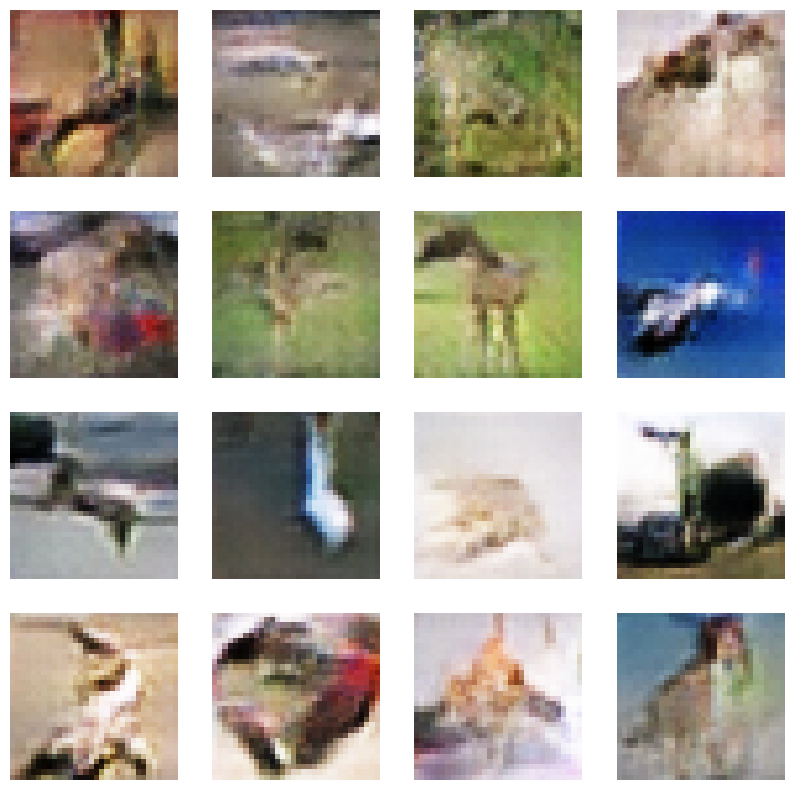

196/196 ━━━━━━━━━━━━━━━━━━━━ 25s 127ms/step - d_loss: 1.3399 - g_loss: 0.7892
Epoch 77/100
196/196 ━━━━━━━━━━━━━━━━━━━━ 40s 123ms/step - d_loss: 1.3425 - g_loss: 0.7998
Epoch 78/100
196/196 ━━━━━━━━━━━━━━━━━━━━ 25s 128ms/step - d_loss: 1.3374 - g_loss: 0.7916
Epoch 79/100
196/196 ━━━━━━━━━━━━━━━━━━━━ 40s 124ms/step - d_loss: 1.3363 - g_loss: 0.7915
Epoch 80/100
196/196 ━━━━━━━━━━━━━━━━━━━━ 25s 129ms/step - d_loss: 1.3350 - g_loss: 0.7946
Epoch 81/100
195/196 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - d_loss: 1.3363 - g_loss: 0.7985

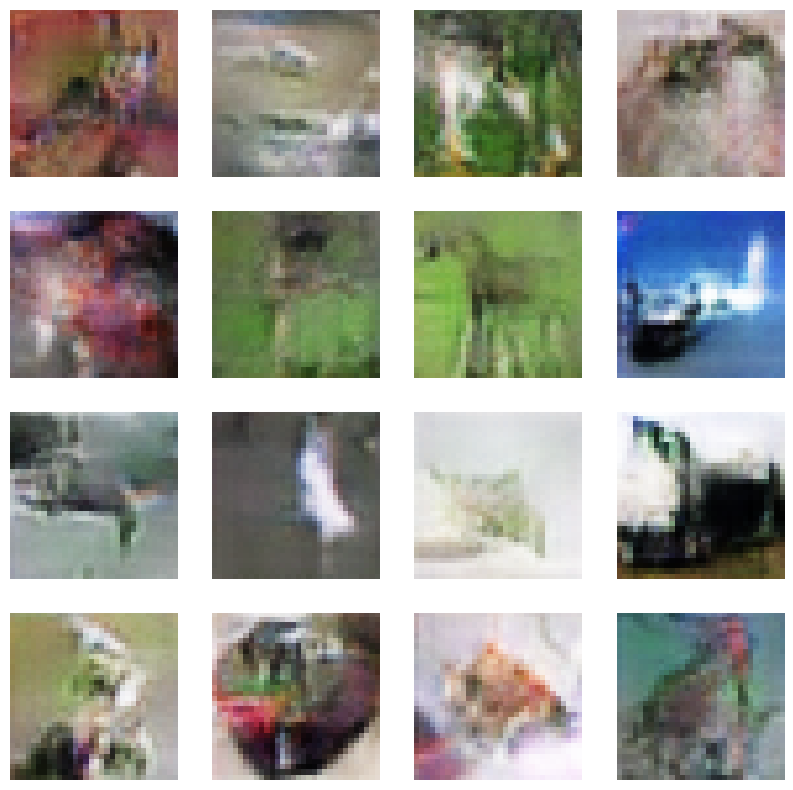

196/196 ━━━━━━━━━━━━━━━━━━━━ 40s 125ms/step - d_loss: 1.3364 - g_loss: 0.7981
Epoch 82/100
196/196 ━━━━━━━━━━━━━━━━━━━━ 25s 128ms/step - d_loss: 1.3327 - g_loss: 0.8002
Epoch 83/100
196/196 ━━━━━━━━━━━━━━━━━━━━ 24s 124ms/step - d_loss: 1.3319 - g_loss: 0.8015
Epoch 84/100
196/196 ━━━━━━━━━━━━━━━━━━━━ 24s 123ms/step - d_loss: 1.3278 - g_loss: 0.7989
Epoch 85/100
196/196 ━━━━━━━━━━━━━━━━━━━━ 25s 125ms/step - d_loss: 1.3301 - g_loss: 0.8129
Epoch 86/100
195/196 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step - d_loss: 1.3257 - g_loss: 0.8126

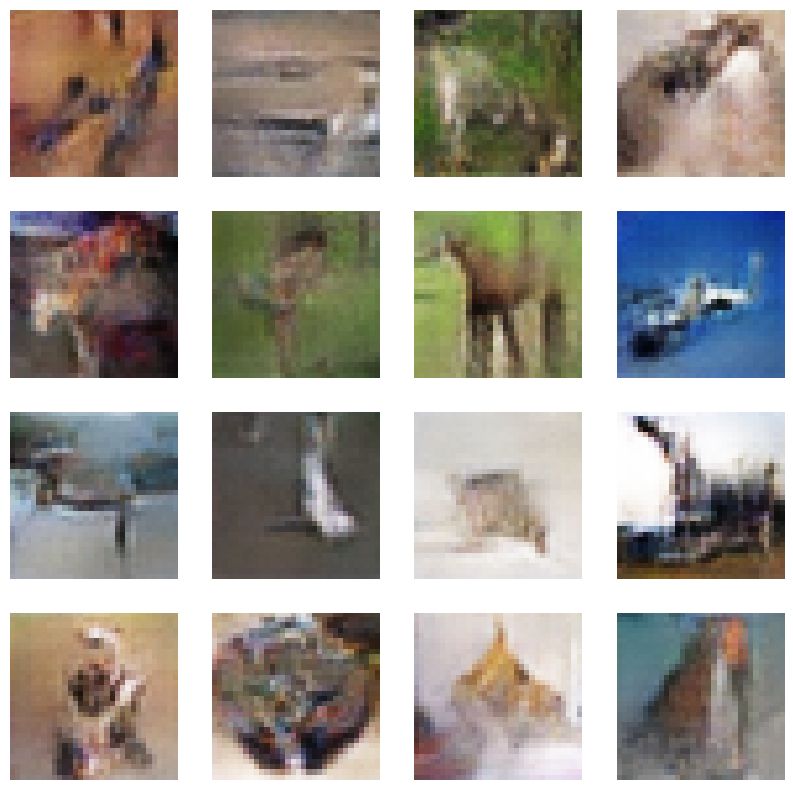

196/196 ━━━━━━━━━━━━━━━━━━━━ 25s 127ms/step - d_loss: 1.3265 - g_loss: 0.8123
Epoch 87/100
196/196 ━━━━━━━━━━━━━━━━━━━━ 40s 124ms/step - d_loss: 1.3241 - g_loss: 0.8050
Epoch 88/100
196/196 ━━━━━━━━━━━━━━━━━━━━ 25s 128ms/step - d_loss: 1.3207 - g_loss: 0.8082
Epoch 89/100
196/196 ━━━━━━━━━━━━━━━━━━━━ 24s 124ms/step - d_loss: 1.3175 - g_loss: 0.8030
Epoch 90/100
196/196 ━━━━━━━━━━━━━━━━━━━━ 24s 123ms/step - d_loss: 1.3184 - g_loss: 0.8155
Epoch 91/100
195/196 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step - d_loss: 1.3232 - g_loss: 0.8304

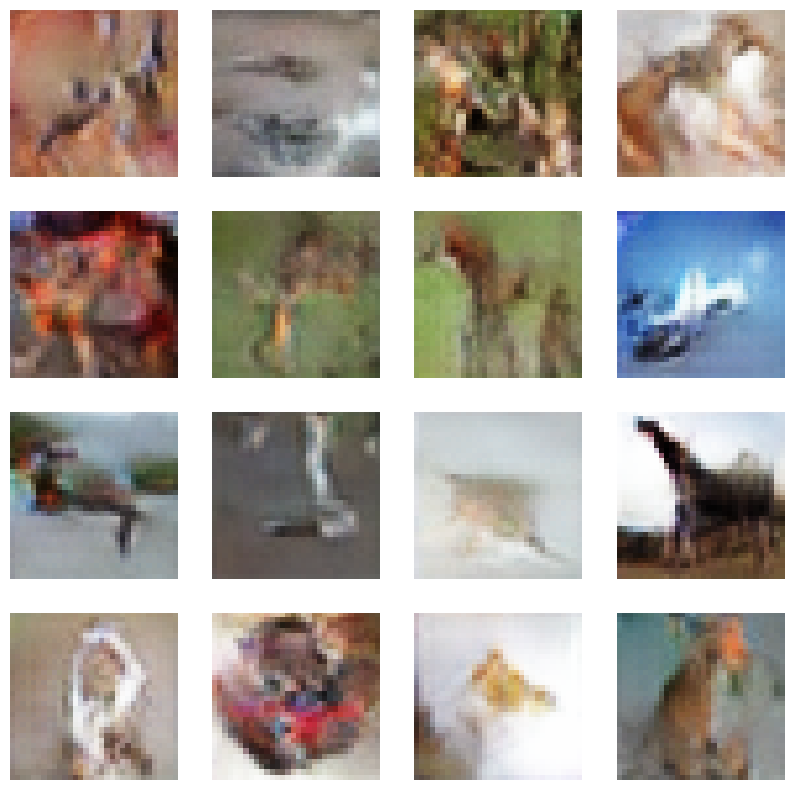

196/196 ━━━━━━━━━━━━━━━━━━━━ 42s 126ms/step - d_loss: 1.3234 - g_loss: 0.8299
Epoch 92/100
196/196 ━━━━━━━━━━━━━━━━━━━━ 25s 127ms/step - d_loss: 1.3130 - g_loss: 0.8162
Epoch 93/100
196/196 ━━━━━━━━━━━━━━━━━━━━ 24s 123ms/step - d_loss: 1.3110 - g_loss: 0.8222
Epoch 94/100
196/196 ━━━━━━━━━━━━━━━━━━━━ 24s 123ms/step - d_loss: 1.3077 - g_loss: 0.8220
Epoch 95/100
196/196 ━━━━━━━━━━━━━━━━━━━━ 25s 125ms/step - d_loss: 1.3092 - g_loss: 0.8369
Epoch 96/100
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - d_loss: 1.3037 - g_loss: 0.8171

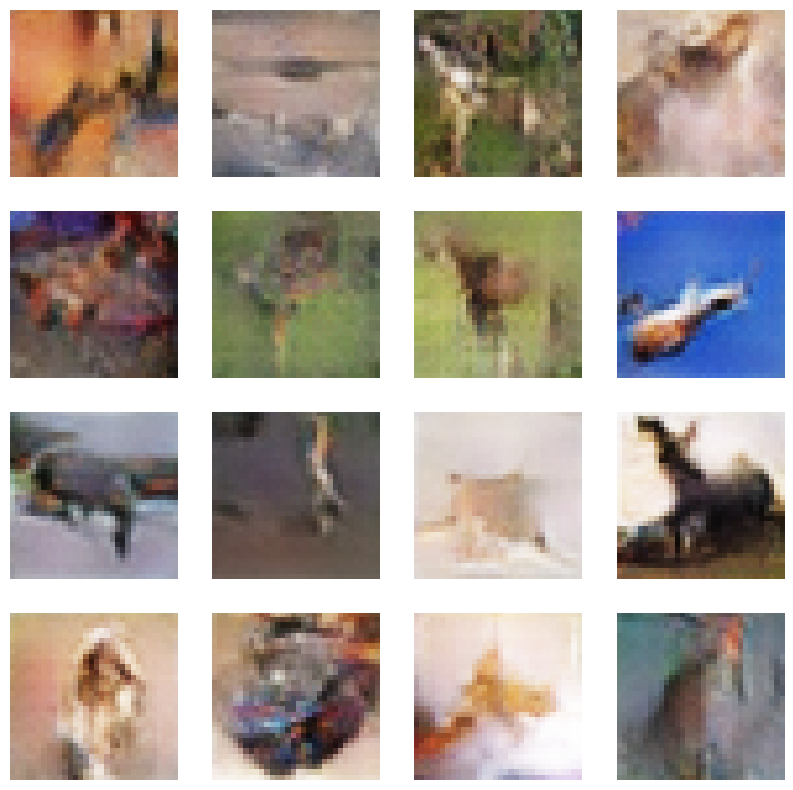

196/196 ━━━━━━━━━━━━━━━━━━━━ 41s 126ms/step - d_loss: 1.3040 - g_loss: 0.8169
Epoch 97/100
196/196 ━━━━━━━━━━━━━━━━━━━━ 25s 128ms/step - d_loss: 1.3003 - g_loss: 0.8242
Epoch 98/100
196/196 ━━━━━━━━━━━━━━━━━━━━ 24s 124ms/step - d_loss: 1.3000 - g_loss: 0.8354
Epoch 99/100
196/196 ━━━━━━━━━━━━━━━━━━━━ 24s 124ms/step - d_loss: 1.2971 - g_loss: 0.8417
Epoch 100/100
196/196 ━━━━━━━━━━━━━━━━━━━━ 41s 125ms/step - d_loss: 1.2931 - g_loss: 0.8394


In [53]:
history = gan.fit(train_dataset, epochs=EPOCH, callbacks=[ImageCallback()])

#### 7. Save and Evaluate the Model

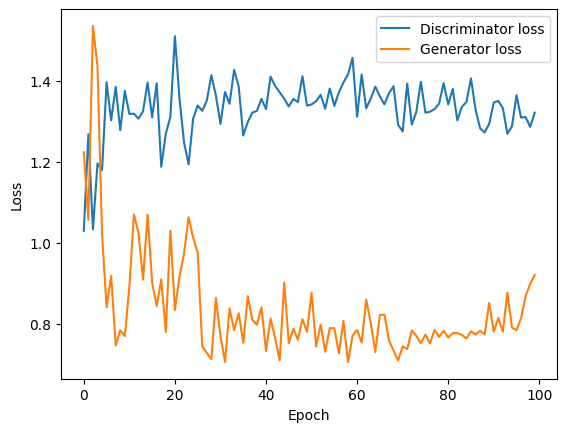

In [54]:
plt.plot(history.history['d_loss'], label='Discriminator loss')
plt.plot(history.history['g_loss'], label='Generator loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [55]:
noise = tf.random.normal([25, LATENT_DIM])
generated_images = generator(noise)
generated_images = (generated_images * 127.5) + 127.5  # Denormalize to range [0, 255]
generated_images = tf.clip_by_value(generated_images, 0, 255)  # Ensure valid pixel range

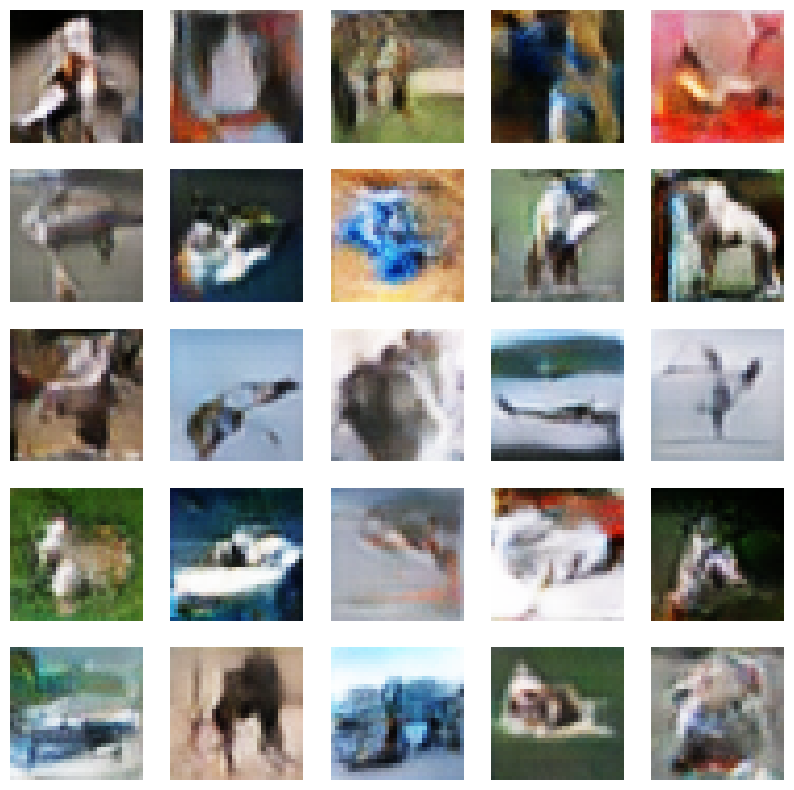

In [56]:
plt.figure(figsize=(10, 10))
for i in range(25):
    plt.subplot(5, 5, i + 1)
    plt.imshow(generated_images[i].numpy().astype("uint8"))
    plt.axis("off")
plt.show()

In [57]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [58]:
generator.save("/content/drive/My Drive/pixel_forge_gan_generator.h5")